#0/ Import thư viện

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#1/ Load ảnh màu RGB

In [19]:
IMAGE_PATH = 'sample/gcl.jpg'

# Load ảnh bằng OpenCV (mặc định là BGR - )
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError(f"❌ Không tìm thấy ảnh tại: {IMAGE_PATH}\n"
                          f"   Vui lòng kiểm tra lại đường dẫn!")

#2/ Chuyển đổi thứ tự kênh màu -> RGB

In [24]:
# Chuyển từ BGR sang RGB (để hiển thị đúng màu với matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

H, W, C = img_rgb.shape

print("Ảnh đã được load và chuyển sang hệ màu RGB")
print(f"  - Đường dẫn ảnh: {IMAGE_PATH}")
print(f"  - Chiều cao (Height): {H} pixels")
print(f"  - Chiều rộng (Width): {W} pixels")
print(f"  - Số kênh màu (Channels): {C}")
print(f"  - Kiểu dữ liệu mỗi pixel: {img_rgb.dtype}")

r, g, b = img_rgb[0, 0]
print("Thông tin pixel tại vị trí (0, 0):")
print(f"  - Red   (R): {r}")
print(f"  - Green (G): {g}")
print(f"  - Blue  (B): {b}")

Ảnh đã được load và chuyển sang hệ màu RGB
  - Đường dẫn ảnh: sample/gcl.jpg
  - Chiều cao (Height): 300 pixels
  - Chiều rộng (Width): 400 pixels
  - Số kênh màu (Channels): 3
  - Kiểu dữ liệu mỗi pixel: uint8
Thông tin pixel tại vị trí (0, 0):
  - Red   (R): 58
  - Green (G): 20
  - Blue  (B): 11


#3/ Tách 3 kênh màu RGB

In [32]:
channel_R = img_rgb[:, :, 0]  # Kênh Red
channel_G = img_rgb[:, :, 1]  # Kênh Green
channel_B = img_rgb[:, :, 2]  # Kênh Blue

H, W = channel_R.shape

print("THÔNG TIN CÁC KÊNH MÀU (R, G, B)")
print(f"  - Kích thước mỗi kênh: {H} x {W} (pixels)")

print("\nGIÁ TRỊ CƯỜNG ĐỘ TRUNG BÌNH")
print(f"  - Kênh Red   (R): {channel_R.mean():.2f}")
print(f"  - Kênh Green (G): {channel_G.mean():.2f}")
print(f"  - Kênh Blue  (B): {channel_B.mean():.2f}")

THÔNG TIN CÁC KÊNH MÀU (R, G, B)
  - Kích thước mỗi kênh: 300 x 400 (pixels)

GIÁ TRỊ CƯỜNG ĐỘ TRUNG BÌNH
  - Kênh Red   (R): 157.57
  - Kênh Green (G): 150.39
  - Kênh Blue  (B): 142.45


#4/ Chuyển ành màu sang xám

In [33]:
img_gray_manual = (0.299 * channel_R +
                   0.587 * channel_G +
                   0.114 * channel_B).astype(np.uint8)

# So sánh với hàm OpenCV (sử dụng cùng công thức)
img_gray_opencv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

H, W = img_gray_manual.shape

diff = img_gray_manual.astype(int) - img_gray_opencv.astype(int)
abs_diff = np.abs(diff)

print("KẾT QUẢ CHUYỂN ĐỔI ẢNH RGB → ẢNH XÁM")
print(f"  - Kích thước ảnh xám: {H} x {W} (pixels)")
print(f"  - Kiểu dữ liệu ảnh xám (manual): {img_gray_manual.dtype}")
print(f"  - Kiểu dữ liệu ảnh xám (OpenCV): {img_gray_opencv.dtype}")

print("SO SÁNH PHƯƠNG PHÁP MANUAL VÀ OPENCV")
print(f"  - Sai số nhỏ nhất giữa các pixel: {abs_diff.min()}")
print(f"  - Sai số lớn nhất giữa các pixel: {abs_diff.max()}")
print(f"  - Sai số trung bình giữa các pixel: {abs_diff.mean():.4f}")

num_diff = np.count_nonzero(abs_diff)
total_pixel = H * W
print(f"  - Số pixel có sai khác: {num_diff} / {total_pixel}")
print(f"  - Tỷ lệ pixel sai khác: {num_diff / total_pixel * 100:.6f}%")

KẾT QUẢ CHUYỂN ĐỔI ẢNH RGB → ẢNH XÁM
  - Kích thước ảnh xám: 300 x 400 (pixels)
  - Kiểu dữ liệu ảnh xám (manual): uint8
  - Kiểu dữ liệu ảnh xám (OpenCV): uint8
SO SÁNH PHƯƠNG PHÁP MANUAL VÀ OPENCV
  - Sai số nhỏ nhất giữa các pixel: 0
  - Sai số lớn nhất giữa các pixel: 1
  - Sai số trung bình giữa các pixel: 0.5011
  - Số pixel có sai khác: 60127 / 120000
  - Tỷ lệ pixel sai khác: 50.105833%


#5/ Kết hợp các kênh màu
- Hoán đổi kênh màu
- Thay thế 1 kênh nào đó bằng 1 giá trị bất kì
   - Đăt 1 kênh bằng 0
   - Thay 1 kênh bằng kênh khác

In [35]:
# 4a. Tái tạo lại ảnh màu ban đầu
img_reconstructed = cv2.merge([channel_R, channel_G, channel_B])

# 4b. Hoán đổi kênh màu
img_BGR = cv2.merge([channel_B, channel_G, channel_R])
img_GBR = cv2.merge([channel_G, channel_B, channel_R])
img_RBG = cv2.merge([channel_R, channel_B, channel_G])

# 4c. Thay thế kênh
img_RG_gray = cv2.merge([channel_R, channel_G, img_gray_manual])
img_R_R_B = cv2.merge([channel_R, channel_R, channel_B])
img_no_R = cv2.merge([np.zeros_like(channel_R), channel_G, channel_B])
img_no_G = cv2.merge([channel_R, np.zeros_like(channel_G), channel_B])
img_no_B = cv2.merge([channel_R, channel_G, np.zeros_like(channel_B)])

#6/ Kết quả

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

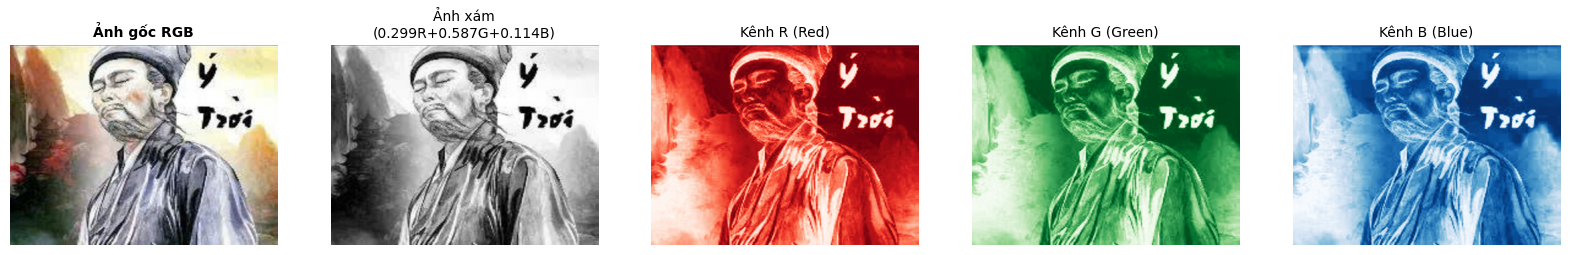

In [44]:
plt.figure(figsize=(20, 12))

plt.subplot(4, 5, 1)
plt.imshow(img_rgb)
plt.title('Ảnh gốc RGB', fontsize=10, fontweight='bold')
plt.axis('off')

plt.subplot(4, 5, 2)
plt.imshow(img_gray_manual, cmap='gray')
plt.title('Ảnh xám\n(0.299R+0.587G+0.114B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 3)
plt.imshow(channel_R, cmap='Reds')
plt.title('Kênh R (Red)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 4)
plt.imshow(channel_G, cmap='Greens')
plt.title('Kênh G (Green)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 5)
plt.imshow(channel_B, cmap='Blues')
plt.title('Kênh B (Blue)', fontsize=10)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

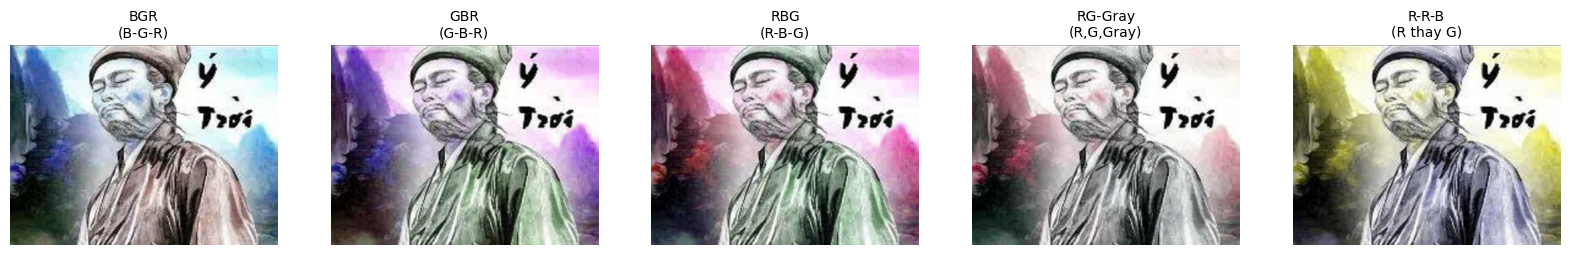

In [47]:
plt.figure(figsize=(20, 12))

plt.subplot(4, 5, 6)
plt.imshow(img_BGR)
plt.title('BGR\n(B-G-R)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 7)
plt.imshow(img_GBR)
plt.title('GBR\n(G-B-R)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 8)
plt.imshow(img_RBG)
plt.title('RBG\n(R-B-G)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 9)
plt.imshow(img_RG_gray)
plt.title('RG-Gray\n(R,G,Gray)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 10)
plt.imshow(img_R_R_B)
plt.title('R-R-B\n(R thay G)', fontsize=10)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

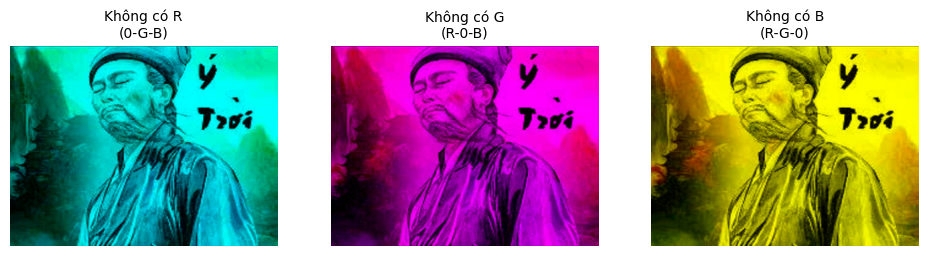

In [48]:
plt.figure(figsize=(20, 12))

plt.subplot(4, 5, 11)
plt.imshow(img_no_R)
plt.title('Không có R\n(0-G-B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 12)
plt.imshow(img_no_G)
plt.title('Không có G\n(R-0-B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 13)
plt.imshow(img_no_B)
plt.title('Không có B\n(R-G-0)', fontsize=10)
plt.axis('off')

#7/ Histogran so sánh

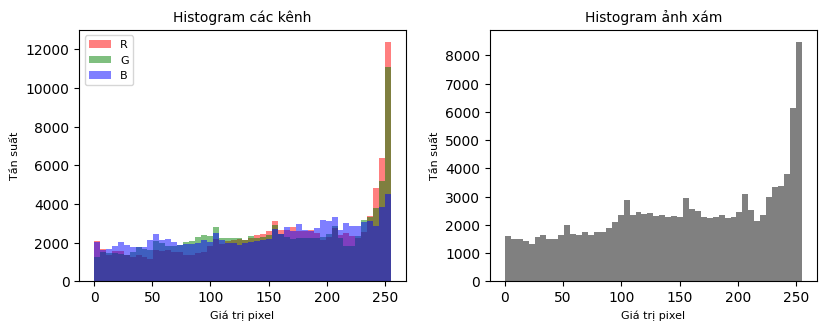

In [49]:
plt.figure(figsize=(20, 12))

plt.subplot(4, 5, 14)
plt.hist(channel_R.ravel(), bins=50, alpha=0.5, color='red', label='R')
plt.hist(channel_G.ravel(), bins=50, alpha=0.5, color='green', label='G')
plt.hist(channel_B.ravel(), bins=50, alpha=0.5, color='blue', label='B')
plt.title('Histogram các kênh', fontsize=10)
plt.legend(fontsize=8)
plt.xlabel('Giá trị pixel', fontsize=8)
plt.ylabel('Tần suất', fontsize=8)

plt.subplot(4, 5, 15)
plt.hist(img_gray_manual.ravel(), bins=50, color='gray')
plt.title('Histogram ảnh xám', fontsize=10)
plt.xlabel('Giá trị pixel', fontsize=8)
plt.ylabel('Tần suất', fontsize=8)

plt.tight_layout()
plt.show()